1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. LOAD DATASET

In [ ]:
df = pd.read_csv("openfoodfacts_nutrition_final_2025-12-10.csv")

df.head()

,code,product_name,brands,countries,quantity,categories,labels,nutriscore_grade,ecoscore_grade,nova_group,ingredients_text,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,6111035000430,Sidi Ali,سيدي علي,Morocco,33 cl,"Beverages and beverages preparations,Beverages...",NaN,a,not-applicable,NaN,OBD1 999 999 1112606 266963207 mb,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000
1,6111242100992,perly,perly,"Morocco,United States",100 g,"Dairies,Fermented foods,Fermented milk product...",NaN,unknown,b,3.0,"milk cream, cream, sugar, banana, bacteria",97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,NaN
2,6111035002175,Sidi Ali,Sidi Ali,Morocco,2 L,"Beverages and beverages preparations,Beverages...",Green Dot,a,not-applicable,1.0,"Sodium, Calcium, Magnésium, Potassium, Bicarbo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",Morocco,"1,5 L","Beverages and beverages preparations,Beverages...","ISO 22000,ISO 14001,ISO 45001,ISO 9001",a,not-applicable,1.0,100% mineral water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000
4,6111252421568,اكوافينا,AQUAFINA,المغرب,33cl,"Boissons et préparations de boissons,Boissons,...",NaN,a,not-applicable,NaN,ouverture et avant le : Voir bouteille. après ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                9804 non-null   int64  
 1   product_name        9566 non-null   object 
 2   brands              9430 non-null   object 
 3   countries           9802 non-null   object 
 4   quantity            8816 non-null   object 
 5   categories          9683 non-null   object 
 6   labels              7552 non-null   object 
 7   nutriscore_grade    9801 non-null   object 
 8   ecoscore_grade      9802 non-null   object 
 9   nova_group          8959 non-null   float64
 10  ingredients_text    9406 non-null   object 
 11  energy-kcal_100g    9280 non-null   float64
 12  fat_100g            9309 non-null   float64
 13  saturated-fat_100g  9140 non-null   float64
 14  carbohydrates_100g  9284 non-null   float64
 15  sugars_100g         9168 non-null   float64
 16  fiber_

3. DATA CLEANING

🔹 Missing Values

In [ ]:
print(df.isnull().sum())
df = df.dropna()

code                     0
product_name           238
brands                 374
countries                2
quantity               988
categories             121
labels                2252
nutriscore_grade         3
ecoscore_grade           2
nova_group             845
ingredients_text       398
energy-kcal_100g       524
fat_100g               495
saturated-fat_100g     664
carbohydrates_100g     520
sugars_100g            636
fiber_100g            2967
proteins_100g          500
salt_100g              663
sodium_100g            663
dtype: int64


🔹 Duplicate Values

In [ ]:
df = df.drop_duplicates().sum()

4. SELECT RELEVANT COLUMNS

In [ ]:
df = df[['energy-kcal_100g', 'fat_100g', 'carbohydrates_100g',
         'proteins_100g', 'sugars_100g']]

In [ ]:
df = df[['energy-kcal_100g', 'fat_100g', 'carbohydrates_100g',
         'proteins_100g', 'sugars_100g']]


print(df.head())

energy-kcal_100g      1.366444e+06
fat_100g              6.290552e+04
carbohydrates_100g    1.561870e+05
proteins_100g         3.551306e+04
sugars_100g           5.236506e+04
dtype: float64


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,5.236506e+04,6.290552e+04,1.561870e+05,1.366444e+06
energy-kcal_100g,False,False,False,True
fat_100g,False,True,False,False
carbohydrates_100g,False,False,True,False
proteins_100g,False,False,False,False
sugars_100g,True,False,False,False


5. STATISTICAL SUMMARY

In [ ]:
print(df.describe())

       energy-kcal_100g     fat_100g  carbohydrates_100g  proteins_100g  \
count       5085.000000  5085.000000         5085.000000    5085.000000   
mean         308.231535    14.562911           34.655926       7.823715   
std          206.024603    17.805356           27.580496       6.730309   
min            0.000000     0.000000            0.000000       0.000000   
25%          126.000000     1.900000            7.000000       3.200000   
50%          336.000000     7.870000           32.500000       7.000000   
75%          453.000000    21.000000           60.700000      10.000000   
max         5280.000000   140.000000          115.000000      80.700000   

       sugars_100g  
count  5085.000000  
mean     11.942399  
std      17.024084  
min       0.000000  
25%       1.400000  
50%       4.200000  
75%      16.000000  
max     113.000000  


6. CORRELATION ANALYSIS

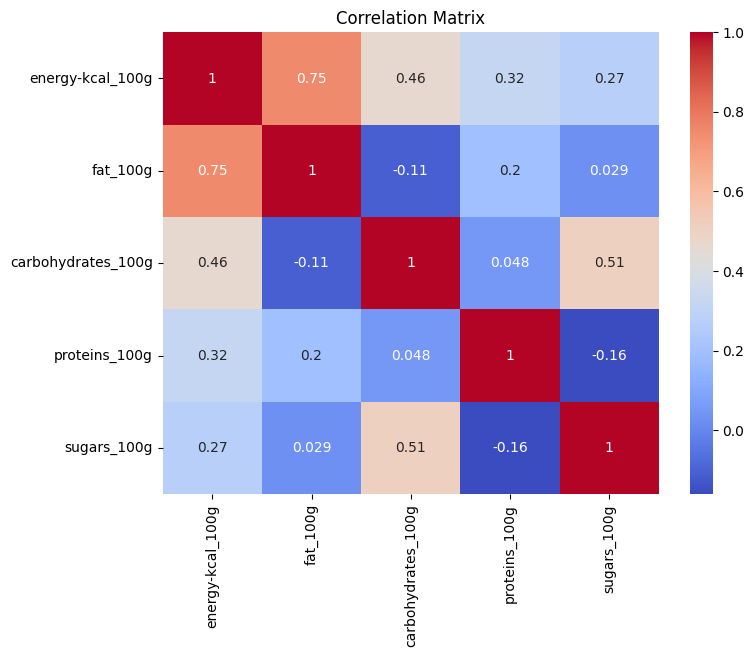

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

7. HISTOGRAM (EDA)

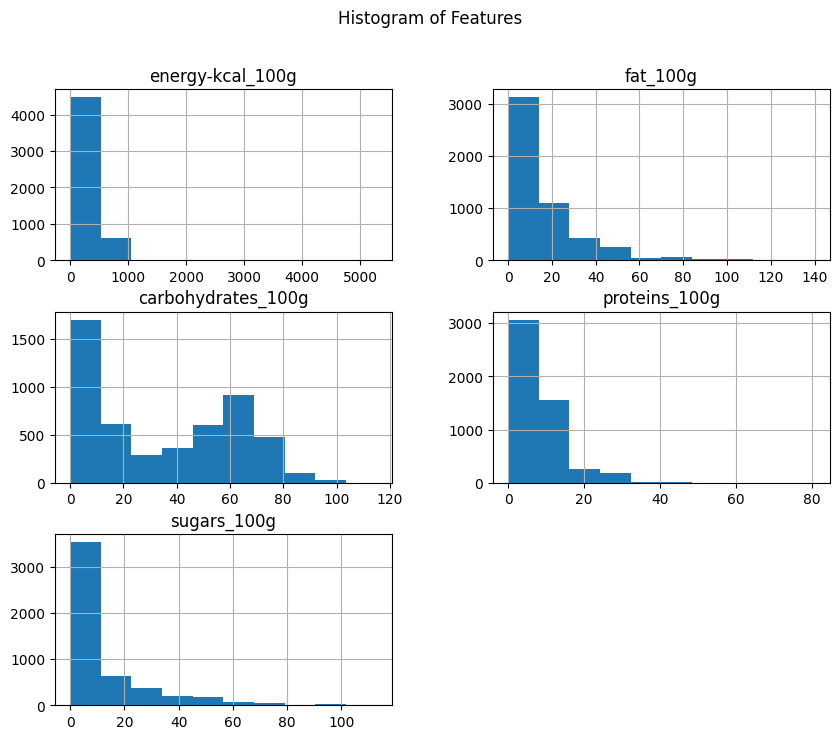

In [ ]:
df.hist(figsize=(10,8))
plt.suptitle("Histogram of Features")
plt.show()

8. BAR GRAPH

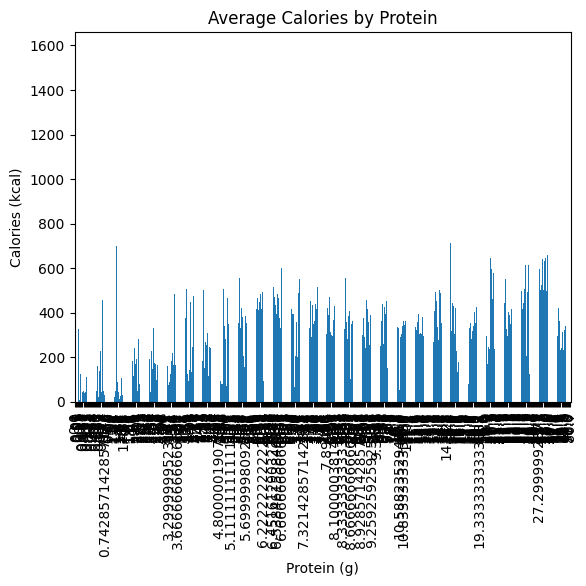

In [ ]:
df.groupby('proteins_100g')['energy-kcal_100g'].mean().plot(kind='bar')
plt.title("Average Calories by Protein")
plt.xlabel("Protein (g)")
plt.ylabel("Calories (kcal)")
plt.show()

9. SKEWNESS

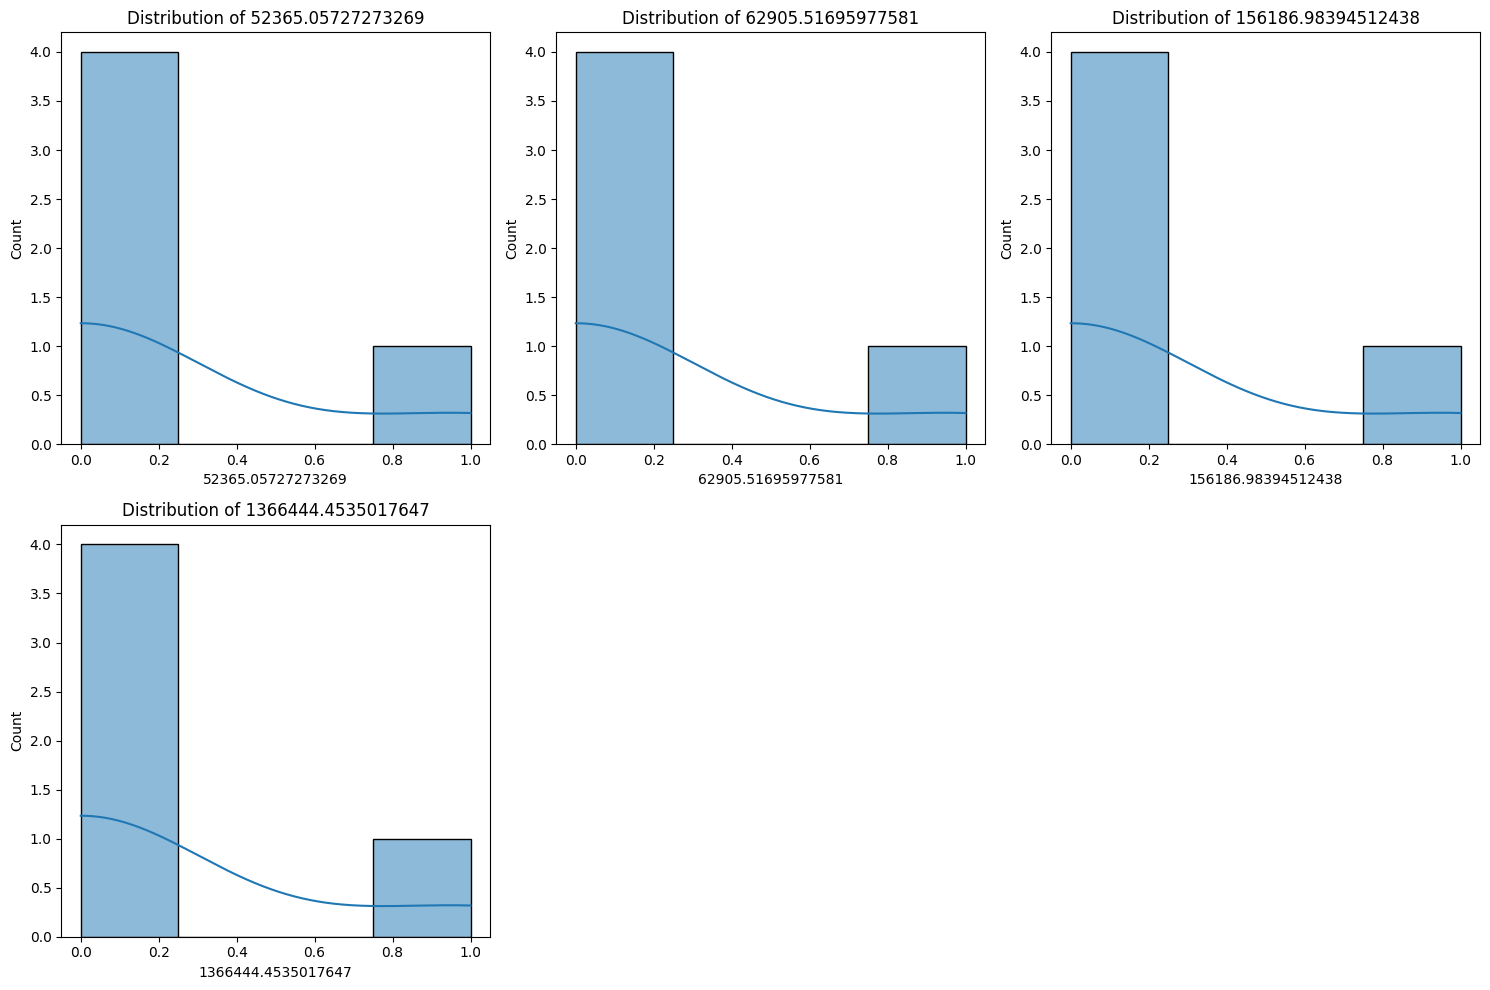

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

numeric_cols = df.columns.tolist()
for i, col in enumerate(numeric_cols[:6]):  # first 6 columns
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

10. KURTOSIS

Leptokurtic: ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']
Mesokurtic: []
Platykurtic: ['code', 'nova_group', 'carbohydrates_100g']


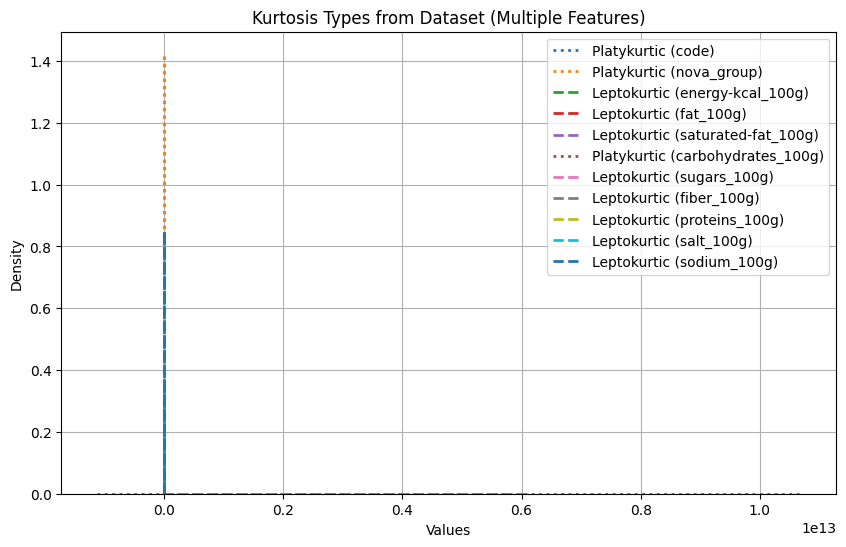

In [ ]:
plt.figure(figsize=(10,6))

for col in df.columns:
    k = df[col].kurtosis()

    # classify
    if k > 3:
        label_type = "Leptokurtic"
        style = '--'
    elif k < 3:
        label_type = "Platykurtic"
        style = ':'
    else:
        label_type = "Mesokurtic"
        style = '-'

    # plot KDE curve
    sns.kdeplot(df[col], linestyle=style, linewidth=2,
                label=f"{label_type} ({col})")

plt.title("Kurtosis Types from Dataset (Multiple Features)")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend()
plt.grid()
lepto = []
meso = []
platy = []

for col in df.columns:
    k = df[col].kurtosis()

    if k > 3:
        lepto.append(col)
    elif k < 3:
        platy.append(col)
    else:
        meso.append(col)

print("Leptokurtic:", lepto)
print("Mesokurtic:", meso)
print("Platykurtic:", platy)
plt.show()

11. Z-TEST (OUTLIER DETECTION)

In [ ]:
z_scores = np.abs(zscore(df))
print(z_scores)

# Remove outliers
df_clean = df[(z_scores < 3).all(axis=1)]

[[1.49623803 0.81797543 1.25666104 1.16257426 0.70156922]
 [0.35548539 0.36156097 1.12974729 0.02619528 0.70156922]
 [0.76099592 0.16497157 1.28161402 0.19669901 1.14893259]
 ...
 [0.59109659 0.07510213 0.78121122 0.54628195 0.06212994]
 [0.99400071 0.75473977 0.88274222 0.40473368 1.17830564]
 [0.61051366 0.03161783 0.99152544 0.32338766 0.12087603]]


12. TRAIN-TEST SPLIT (80-20)

In [ ]:
X = df_clean[['fat_100g', 'carbohydrates_100g', 'proteins_100g', 'sugars_100g']]
y = df_clean['energy-kcal_100g']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
future_data = X_test.head(5)

In [ ]:
future_predictions = model.predict(future_data)

future_df = future_data.copy()
future_df['Predicted Calories'] = future_predictions.round(2)

print(future_df)

      fat_100g  carbohydrates_100g  proteins_100g  sugars_100g  \
7752      18.0                 1.3           17.0          0.8   
4215       1.6                13.0            1.0          1.0   
2471      14.0                65.0            6.8          1.4   
5440      24.6                 0.2           16.2          0.2   
3754       3.4                72.3           12.4         70.2   

      Predicted Calories  
7752              242.87  
4215               73.33  
2471              420.69  
5440              294.46  
3754              377.03  


13. MACHINE LEARNING MODEL

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

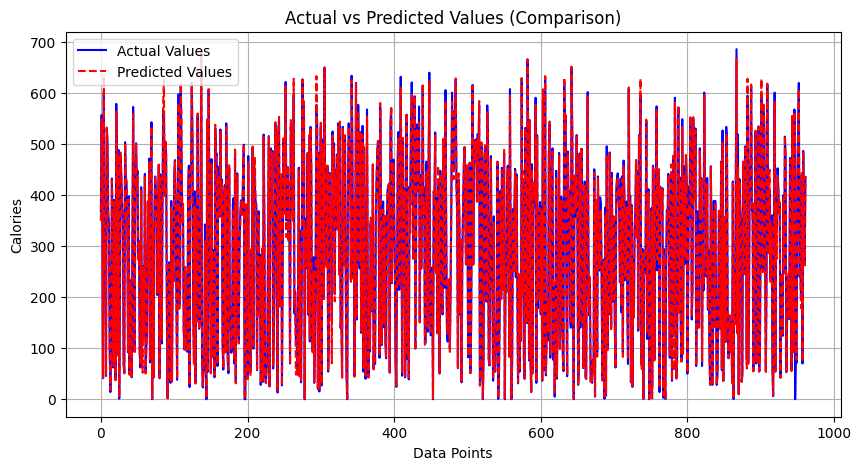

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Values", color='blue')
plt.plot(y_pred, label="Predicted Values", linestyle='dashed', color='red')

plt.title("Actual vs Predicted Values (Comparison)")
plt.xlabel("Data Points")
plt.ylabel("Calories")

plt.legend()
plt.grid()

plt.show()

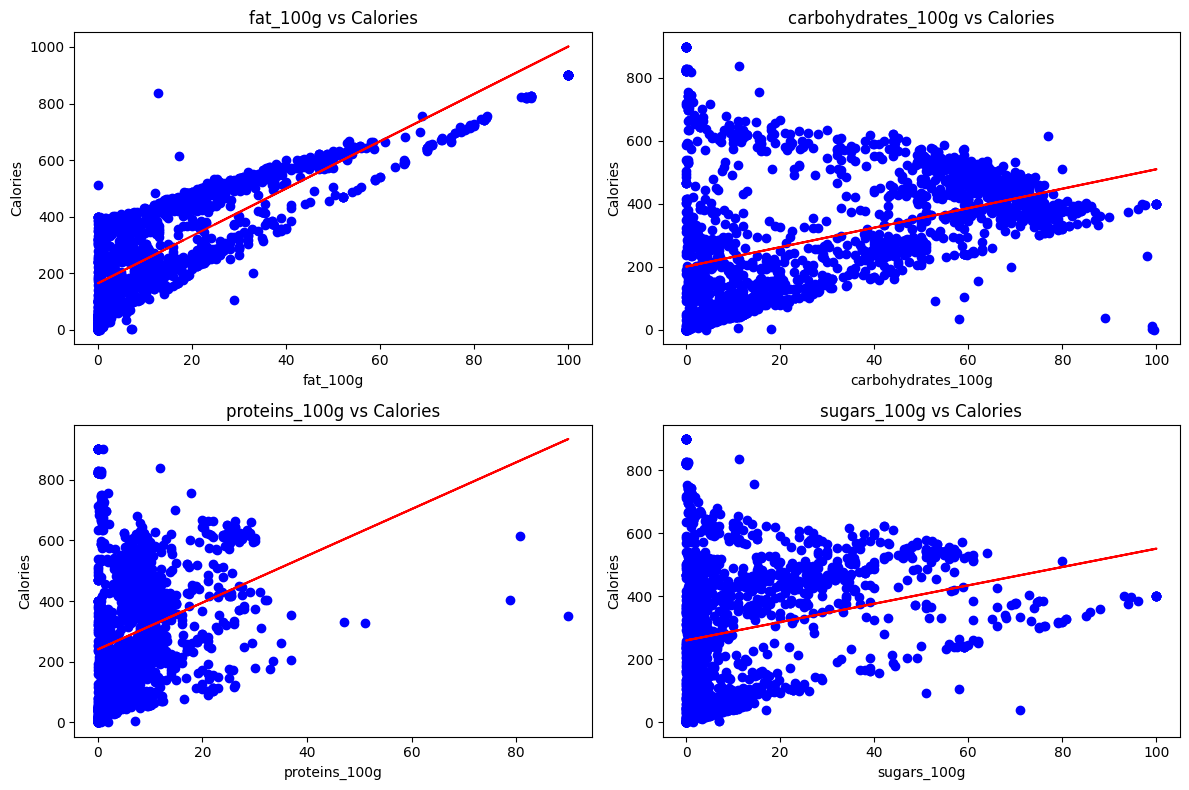

In [ ]:
features = X.columns

plt.figure(figsize=(12,8))

for i, col in enumerate(features):
    plt.subplot(2,2,i+1)

    plt.scatter(X_test[col], y_test, color='blue')

    # regression line
    m, b = np.polyfit(X_test[col], y_test, 1)
    plt.plot(X_test[col], m*X_test[col] + b, color='red')

    plt.title(f"{col} vs Calories")
    plt.xlabel(col)
    plt.ylabel("Calories")

plt.tight_layout()
plt.show()

14. MODEL EVALUATION

In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 325.8135574941569
R2 Score: 0.9900114709135575


15. PREDICTION GRAPH

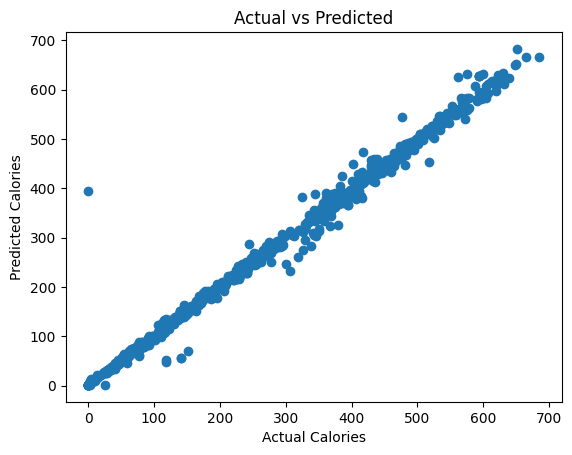

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted")
plt.show()